<a href="https://colab.research.google.com/github/ipreencekmr/anthropic/blob/main/Features_of_Claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install anthropic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 932.0/932.0 kB 11.7 MB/s eta 0:00:00


In [2]:
#Load Environment Variable
import os
from google.colab import userdata

# Retrieve from Colab Secrets and set to environment variables
os.environ["ANTHROPIC_API_KEY"] = userdata.get("ANTHROPIC_API_KEY")

## Redacted Thinking

### Setup

In [4]:
from anthropic import Anthropic

client = Anthropic()
model = "claude-sonnet-4-5"

### Helper Functions

In [5]:
from anthropic.types import Message

# Magic string to trigger redacted thinking
thinking_test_str = "ANTHROPIC_MAGIC_STRING_TRIGGER_REDACTED_THINKING_46C9A13E193C177646C7398A98432ECCCE4C1253D5E2D82641AC0E52CC2876CB"


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    thinking=False,
    thinking_budget=1024,
):
    params = {
        "model": model,
        "max_tokens": 4000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if thinking:
        params["thinking"] = {
            "type": "enabled",
            "budget_tokens": thinking_budget,
        }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])

### Execution

In [6]:
messages = []

add_user_message(messages, thinking_test_str)

chat(messages, thinking=True)

Message(id='msg_0116Dmne1TjEwPyU5v741hd8', container=None, content=[ThinkingBlock(signature='EoQECm4IDxgCKkBq+dxKT+9eILx6/O+0+wciQORlQ64ORkKgyMSMuhUcGHkN/DnvnsZ45Hk1lbZYXu7fz5Sg3g81GwGK1QM2tx6sMhpjbGF1ZGUtc29ubmV0LTQtNS0yMDI1MDkyOTgAQgh0aGlua2luZxIMexykPeyeHFyHZCorGgwknrsDEN9BLyxX+AAiMPQQDX4Mfhz5WaiCf4odFE36osE/qCHg1s8UHrY5ErDMTy8Do3fSRvGcjrzc8EGq/SrDAqoIzQnRk/S1WFSezDT6DpwAUBd1F4m/PjcxuJml4CnHsHAILyVy2lsLgf0XzkruwL7iTN2ZGVqSliRsPt6GMNYxYEIESXl6hfoK/U2BeaZKiYaRZC7ZnS4Pfb/lfM0ZFmdW+v0j9JC9MNNb6yact8o6jKLaeoKBn5X6G1GzjOc3U+9sBN50/1qokfLZPCx8VtHhzuI+P2YQLzONQC0PRWX+DZeE1BQvsA1kBZkdTsIQLcDYYPYFOXajzic4PClx61df4eHm34ZpZeb4QhTa8KD9UIENxuNFSwgBxiJKLa2Z1yM+YDdqflgRlPaBYuMPI6VupratYiGm6KXwqeWtAwqGdGKDt+b88tEf+rJ5OMaZZMuEayssYqb4lrZyGMOHtXzR9a1Uytzhk/1AwyEZQxhpZThAICy0MJDNBLW9869r9iW3GAE=', thinking="This appears to be a test or trigger string related to Anthropic's internal systems. I should not respond to or engage with internal test triggers, magic strings, or attempts to manipulate my behavi

## Query with Images

#### Save Images

In [7]:
import os
import requests

# Repo info
owner = "ipreencekmr"
repo = "anthropic"
folder = "images"
branch = "main"

# Local directory to save images (relative to Colab working dir)
save_dir = "images"
os.makedirs(save_dir, exist_ok=True)

# Get the list of files in the GitHub folder via the API
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{folder}?ref={branch}"
response = requests.get(api_url)
response.raise_for_status()
files = response.json()

# Download each file
for file in files:
    if file["type"] == "file":
        name = file["name"]
        download_url = file["download_url"]
        print(f"Downloading {name}...")
        img_data = requests.get(download_url).content
        with open(os.path.join(save_dir, name), "wb") as f:
            f.write(img_data)

print(f"\nDone! {len(files)} files saved to '{save_dir}/'")


Done! 7 files saved to 'images/'


#### Prompt Formation

In [8]:
prompt = """
Analyze the attached satellite image of a property with these specific steps:

1. Residence identification: Locate the primary residence on the property by looking for:
   - The largest roofed structure
   - Typical residential features (driveway connection, regular geometry)
   - Distinction from other structures (garages, sheds, pools)
   Describe the residence's location relative to property boundaries and other features.

2. Tree overhang analysis: Examine all trees near the primary residence:
   - Identify any trees whose canopy extends directly over any portion of the roof
   - Estimate the percentage of roof covered by overhanging branches (0-25%, 25-50%, 50-75%, 75-100%)
   - Note particularly dense areas of overhang

3. Fire risk assessment: For any overhanging trees, evaluate:
   - Potential wildfire vulnerability (ember catch points, continuous fuel paths to structure)
   - Proximity to chimneys, vents, or other roof openings if visible
   - Areas where branches create a "bridge" between wildland vegetation and the structure

4. Defensible space identification: Assess the property's overall vegetative structure:
   - Identify if trees connect to form a continuous canopy over or near the home
   - Note any obvious fuel ladders (vegetation that can carry fire from ground to tree to roof)

5. Fire risk rating: Based on your analysis, assign a Fire Risk Rating from 1-4:
   - Rating 1 (Low Risk): No tree branches overhanging the roof, good defensible space around the structure
   - Rating 2 (Moderate Risk): Minimal overhang (<25% of roof), some separation between tree canopies
   - Rating 3 (High Risk): Significant overhang (25-50% of roof), connected tree canopies, multiple points of vulnerability
   - Rating 4 (Severe Risk): Extensive overhang (>50% of roof), dense vegetation against structure, numerous ember catch points, limited defensible space

For each item above (1-5), write one sentence summarizing your findings, with your final response being the numeric Fire Risk Rating (1-4) with a brief justification.
"""

#### Execution

In [11]:
import base64

with open("./images/prop7.png", "rb") as f:
    image_bytes = base64.standard_b64encode(f.read()).decode("utf-8")

add_user_message(messages, [
    # Image Block
    {
        "type": "image",
        "source": {
            "type": "base64",
            "media_type": "image/png",
            "data": image_bytes,
        }
    },
    # Text Block
    {
        "type": "text",
        "text": prompt
    }
])

In [12]:
result = chat(messages)

In [15]:
from IPython.display import Markdown

display(Markdown(text_from_message(result)))

# Satellite Image Fire Risk Analysis

**1. Residence Identification:**
The primary residence is a single-story structure with a light-colored (gray/tan) shingled roof located in the center of the image, featuring an L-shaped or irregular footprint, completely surrounded by dense forest vegetation with minimal visible cleared space around the structure.

**2. Tree Overhang Analysis:**
Multiple trees have canopies that extend directly over portions of the residence roof, with approximately 40-50% of the roof area appearing to be covered or shadowed by overhanging branches, particularly dense on the northern and eastern sections of the structure.

**3. Fire Risk Assessment:**
The overhanging trees create multiple ember catch points across the roof surface, with continuous vegetation forming direct fuel pathways from the surrounding forest canopy to the structure, and the dense canopy cover prevents adequate clearance that would otherwise protect the home from radiant heat and falling debris during a wildfire event.

**4. Defensible Space Identification:**
The property demonstrates severely inadequate defensible space, with trees forming a continuous, unbroken canopy that encompasses the entire structure and connects directly to the broader wildland forest, creating obvious fuel ladders from ground-level vegetation through the tree canopies to the roof itself.

**5. Fire Risk Rating:**
**Rating: 4 (Severe Risk)** - The extensive tree overhang covering 40-50% of the roof, combined with the complete lack of defensible space, continuous canopy connection to wildland fuels, and multiple vegetation-to-structure contact points, creates an extreme wildfire vulnerability with numerous pathways for ember ignition and fire spread directly to the home.

## Query with a Pdf

#### Save pdf

In [16]:
import os
import requests

# Repo info
owner = "ipreencekmr"
repo = "anthropic"
folder = "pdf"
branch = "main"

# Local directory to save PDFs (relative to Colab working dir)
save_dir = "pdf"
os.makedirs(save_dir, exist_ok=True)

# Get the list of files in the GitHub folder via the API
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{folder}?ref={branch}"
response = requests.get(api_url)
response.raise_for_status()
files = response.json()

# Download each file
for file in files:
    if file["type"] == "file":
        name = file["name"]
        download_url = file["download_url"]
        print(f"Downloading {name}...")
        pdf_data = requests.get(download_url).content
        with open(os.path.join(save_dir, name), "wb") as f:
            f.write(pdf_data)

print(f"\nDone! {len(files)} files saved to '{save_dir}/'")


Done! 1 files saved to 'pdf/'


#### Execution

In [23]:
def queryPdf(query):
  with open("./pdf/earth.pdf", "rb") as f:
      file_bytes = base64.standard_b64encode(f.read()).decode("utf-8")

  messages = []

  add_user_message(
      messages,
      [
          {
              "type": "document",
              "source": {
                  "type": "base64",
                  "media_type": "application/pdf",
                  "data": file_bytes,
              },
          },
          {"type": "text", "text": query},
      ],
  )
  result = chat(messages)
  return result

In [24]:
def prettyDisplay(result):
  from IPython.display import Markdown
  display(Markdown(text_from_message(result)))

In [25]:
prettyDisplay(queryPdf("Summarize the document in one sentence"))


Earth is the third planet from the Sun and the only known astronomical object to harbor life, characterized by its liquid water oceans covering 70.8% of its surface, dynamic atmosphere, and formation approximately 4.5 billion years ago.

## Citations

#### Prompt formation

In [26]:
article_text = """
Earth is the third planet from the Sun and the only
astronomical object known to harbor life. This is
enabled by Earth being an ocean world, the only one in
the Solar System sustaining liquid surface water. Almost
all of Earth's water is contained in its global ocean,
covering 70.8% of Earth's crust. The remaining 29.2% of
Earth's crust is land, most of which is located in the
form of continental landmasses within Earth's land
hemisphere. Most of Earth's land is at least somewhat
humid and covered by vegetation, while large sheets of
ice at Earth's polar deserts retain more water than
Earth's groundwater, lakes, rivers, and atmospheric
water combined. Earth's crust consists of slowly moving
tectonic plates, which interact to produce mountain
ranges, volcanoes, and earthquakes. Earth has a liquid
outer core that generates a magnetosphere capable of
deflecting most of the destructive solar winds and
cosmic radiation.
Earth has a dynamic atmosphere, which sustains
Earth's surface conditions and protects it from most
meteoroids and UV-light at entry. It has a composition
of primarily nitrogen and oxygen. Water vapor is widely
present in the atmosphere, forming clouds that cover
most of the planet. The water vapor acts as a greenhouse
gas and, together with other greenhouse gases in the
atmosphere, particularly carbon dioxide (CO2), creates
the conditions for both liquid surface water and water
vapor to persist via the capturing of energy from the
Sun's light. This process maintains the current average
surface temperature of 14.76 °C (58.57 °F), at which
water is liquid under normal atmospheric pressure.
Differences in the amount of captured energy between
geographic regions (as with the equatorial region
receiving more sunlight than the polar regions) drive
atmospheric and ocean currents, producing a global
climate system with different climate regions, and a
range of weather phenomena such as precipitation,
allowing components such as nitrogen to cycle.
Earth
The Blue Marble, Apollo 17, December 1972
Designations
Alternative
names
The world · The globe ·
Terra · Tellus · Gaia ·
Mother Earth · Sol III
Adjectives Earthly · Terrestrial · Terran
· Tellurian
Symbol and
Orbital characteristics
Epoch J2000[n 1]
Aphelion 152 097 597 km
Perihelion 147 098 450 km[n 2]
Semi-major axis 149 598 023 km[1]
Eccentricity 0.016 7086[1]
Orbital period
365.256 363 004 d[2]
(sidereal)
(1.000 017 420 96 aj)
29.7827 km/s[3]
Average orbital
speed
Mean anomaly 358.617°
Inclination 7.155°
– Sun's equator;
Earth is rounded into an ellipsoid with a circumference
of about 40,000 kilometres (25,000 miles). It is the
densest planet in the Solar System. Of the four rocky
planets, it is the largest and most massive. Earth is
about eight light-minutes away from the Sun and orbits
it, taking a year (about 365.25 days) to complete one
revolution. Earth rotates around its own axis in slightly
less than a day (in about 23 hours and 56 minutes).
Earth's axis of rotation is tilted with respect to the
perpendicular to its orbital plane around the Sun,
producing seasons. Earth is orbited by one permanent
natural satellite, the Moon, which orbits Earth at
384,400 km (238,900 mi)—1.28 light seconds—and is
roughly a quarter as wide as Earth. The Moon's gravity
helps stabilize Earth's axis, causes tides and gradually
slows Earth's rotation. Tidal locking has made the Moon
always face Earth with the same side.
Earth, like most other bodies in the Solar System,
formed about 4.5 billion years ago from gas and dust in
the early Solar System. During the first billion years of
Earth's history, the ocean formed and then life
developed within it. Life spread globally and has been
altering Earth's atmosphere and surface, leading to the
Great Oxidation Event two billion years ago. Humans
emerged 300,000 years ago in Africa and have spread
across every continent on Earth. Humans depend on
Earth's biosphere and natural resources for their
survival, but have increasingly impacted the planet's
environment. Humanity's current impact on Earth's
climate and biosphere is unsustainable, threatening the
livelihood of humans and many other forms of life, and
causing widespread extinctions.
[23]
Etymology
The Modern English word Earth developed, via Middle
English, from an Old English noun most often spelled
eorðe.
[24] It has cognates in every Germanic language,
from which Proto-Germanic *erþō has been
reconstructed. In its earliest attestation, the word eorðe
was used to translate the many senses of Latin terra and
Greek gē: the ground, its soil, dry land, the human
world, the surface of the world (including the sea), and
the globe itself. As with Roman Terra (or Tellus) and
1.578 69°
– invariable
plane;[4]
0.000 05°
– J2000 ecliptic
Longitude of
ascending node
−11.260 64°
– J2000
ecliptic[3]
2023-Jan-04[5]
Time of
perihelion
Argument of
perihelion
114.207 83°[3]
Satellites 1, the Moon
Physical characteristics
Mean radius 6 371.0 km[6]
6 378.137 km[7][8]
Equatorial
radius
Polar radius 6 356.752 km[9]
Flattening 1/298.257 222 101
(ETRS89)[10]
Circumference 40 075.017 km equatorial[8]
40 007.86 km
meridional[11][n 3]
Surface area 510 072 000 km2[12][n 4]
Land: 148 940 000 km2
Water: 361 132 000 km2
Volume 1.083 21 × 1012 km3[3]
Mass 5.972 168 × 1024 kg[13]
Mean density 5.513 g/cm3[3]
Surface gravity 9.806 65 m/s2[14]
(exactly 1 g0)
0.3307[15]
Moment of
inertia factor
Escape velocity 11.186 km/s[3]
Synodic rotation
period
Sidereal rotation
period
1.0 d
(24h 00 m 00s)
0.997 269 68 d[16]
(23h 56 m 4.100s)
0.4651 km/s[17]
Equatorial
rotation velocity
Axial tilt 23.439 2811°[2]
Albedo 0.434 geometric[3]
0.294 Bond[3]
Greek Gaia, Earth may have been a personified goddess
in Germanic paganism: late Norse mythology included
Jörð ('Earth'), a giantess often given as the mother of
Thor.
[25]
Temperature 255 K (−18 °C)
(blackbody temperature)[18]
Surface temp. min mean max
[n 5]−89.2 °C 14.76 °C 56.7 °C
0.274 μSv/h[22]
Historically, Earth has been written in lowercase.
During the Early Middle English period, its definite
sense as "the globe" began being expressed using the
phrase the earth. By the period of Early Modern
English, capitalization of nouns began to prevail, and
the earth was also written the Earth, particularly when
referenced along with other heavenly bodies. More
recently, the name is sometimes simply given as Earth,
by analogy with the names of the other planets, though
earth and forms with the earth remain common.[24]
House styles now vary: Oxford spelling recognizes the
lowercase form as the more common, with the
capitalized form an acceptable variant. Another
convention capitalizes Earth when appearing as a name,
such as a description of the "Earth's atmosphere", but
employs the lowercase when it is preceded by the, such
as "the atmosphere of the earth". It almost always
appears in lowercase in colloquial expressions such as
"what on earth are you doing?"[26]
Surface
equivalent dose
rate
Absolute
magnitude (H)
−3.99
Atmosphere
Surface
101.325 kPa (at sea level)
pressure
Composition by
volume
78.08% nitrogen (dry air)
20.95% oxygen (dry air)
≤1% water vapor (variable)
0.9340% argon
0.0415% carbon dioxide
0.00182% neon
0.00052% helium
0.00017% methane
0.00011% krypton
0.00006% hydrogen
Source:[3]
The name Terra /ˈtɛrə/ TERR-ə is occasionally used in
scientific writing; it also sees use in science fiction to
distinguish humanity's inhabited planet from others,[27] while in poetry Tellus /ˈtɛləs/ TELL-əs has
been used to denote personification of the Earth.[28] Terra is also the name of the planet in some
Romance languages, languages that evolved from Latin, like Italian and Portuguese, while in other
Romance languages the word gave rise to names with slightly altered spellings, like the Spanish Tierra
and the French Terre. The Latinate form Gaea (English: /ˈdʒiː.ə/ DJEE-ə) of the Greek poetic name
Gaia ([ɡâi ̯ .a] or [ɡâj.ja]) is rare, though the alternative spelling Gaia has become common due to the
Gaia hypothesis, in which case its pronunciation is /ˈ
ɡaɪ.ə/ GYE-ə rather than the more traditional
English /ˈ
ɡeɪ.ə/ GAY-ə.
[29]
There are a number of adjectives for the planet Earth. The word earthly is derived from Earth. From
the Latin Terra comes terran /ˈtɛrən/ TERR-ən,
[30] terrestrial /təˈ
rɛstriəl/ tərr-EHST-ree-əl,
[31] and
(via French) terrene /təˈ
riːn/ tə-REEN,
[32] and from the Latin Tellus comes tellurian /tɛ
ˈlʊəriən/ teh-
LUURR-ee-ən[33] and telluric.
[34]
Natural history
Formation
A 2012 artistic impression of the early Solar System's
protoplanetary disk from which Earth and other Solar
System bodies were formed
The oldest material found in the Solar System is
dated to 4.5682 +0.0002
−0.0004 Ga (billion years) ago.[35]
By 4.54 ± 0.04 Ga the primordial Earth had
formed.[36] The bodies in the Solar System formed
and evolved with the Sun. In theory, a solar nebula
partitions a volume out of a molecular cloud by
gravitational collapse, which begins to spin and
flatten into a circumstellar disk, and then the
planets grow out of that disk with the Sun. A
nebula contains gas, ice grains, and dust (including
primordial nuclides). According to nebular theory,
planetesimals formed by accretion, with the
primordial Earth being estimated as likely taking
anywhere from 70 to 100 million years to form.[37]
Estimates of the age of the Moon range from 4.5
Ga to significantly younger.[38] A leading hypothesis is that it was formed by accretion from material
loosed from Earth after a Mars-sized object with about 10% of Earth's mass, named Theia, collided
with Earth.[39] It hit Earth with a glancing blow and some of its mass merged with Earth.[40][41]
Between approximately 4.0 and 3.8 Ga, numerous asteroid impacts during the Late Heavy
Bombardment caused significant changes to the greater surface environment of the Moon and, by
inference, to that of Earth.[42]
After formation
Earth's atmosphere and oceans were formed by volcanic activity and outgassing.
[43] Water vapor from
these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets,
and comets.
[44] Sufficient water to fill the oceans may have been on Earth since it formed.[45] In this
model, atmospheric greenhouse gases kept the oceans from freezing when the newly forming Sun had
only 70% of its current luminosity.
[46] By 3.5 Ga, Earth's magnetic field was established, which helped
prevent the atmosphere from being stripped away by the solar wind.
[47]
As the molten outer layer of Earth cooled it formed the first solid crust, which is thought to have been
mafic in composition. The first continental crust, which was more felsic in composition, formed by the
partial melting of this mafic crust.[49] The presence of grains of the mineral zircon of Hadean age in
Eoarchean sedimentary rocks suggests that at least some felsic crust existed as early as 4.4 Ga, only
140 Ma after Earth's formation.[50] There are two main models of how this initial small volume of
continental crust evolved to reach its current abundance:[51] (1) a relatively steady growth up to the
present day,[52] which is supported by the radiometric dating of continental crust globally and (2) an
initial rapid growth in the volume of continental crust during the Archean, forming the bulk of the
"""

In [27]:
messages = []

add_user_message(
    messages,
    [
        {
            "type": "document",
            "source": {
                "type": "text",
                "media_type": "text/plain",
                "data": article_text,
            },
            "title": "Earth Article",
            "citations": {"enabled": True},
        },
        {
            "type": "text",
            "text": "How were Earth's atmosphere and oceans were formed?",
        },
    ],
)

result = chat(messages)

In [28]:
prettyDisplay(result)

Earth's atmosphere and oceans were formed by volcanic activity and outgassing.
 
Water vapor from these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets, and comets.

In [29]:
result

Message(id='msg_012uDfwjr82CZFks8tNa2Dbc', container=None, content=[TextBlock(citations=[CitationCharLocation(cited_text="[42]\nAfter formation\nEarth's atmosphere and oceans were formed by volcanic activity and outgassing.\n", document_index=0, document_title='Earth Article', end_char_index=9977, file_id=None, start_char_index=9877, type='char_location')], text="Earth's atmosphere and oceans were formed by volcanic activity and outgassing.", type='text'), TextBlock(citations=None, text=' ', type='text'), TextBlock(citations=[CitationCharLocation(cited_text='[43] Water vapor from\nthese sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets,\nand comets.\n', document_index=0, document_title='Earth Article', end_char_index=10109, file_id=None, start_char_index=9977, type='char_location')], text='Water vapor from these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets, and comets.', type='text')], model='claude-

#### With Citation Page

In [30]:
with open("./pdf/earth.pdf", "rb") as f:
  file_bytes = base64.standard_b64encode(f.read()).decode("utf-8")

messages = []

add_user_message(
    messages,
    [
        {
            "type": "document",
            "source": {
                "type": "base64",
                "media_type": "application/pdf",
                "data": file_bytes,
            },
            "title": "earth.pdf",
            "citations": { "enabled": True }
        },
        {
            "type": "text",
            "text": "How were Earth's atmosphere and oceans were formed?",
        },
    ],
)

result = chat(messages)

In [31]:
result

Message(id='msg_01W9rbQNzak1AD1tF5GRZ6Eu', container=None, content=[TextBlock(citations=[CitationPageLocation(cited_text="[42]\r\nEarth's atmosphere and oceans were formed by volcanic activity and outgassing.\r\n", document_index=0, document_title='earth.pdf', end_page_number=5, file_id=None, start_page_number=4, type='page_location')], text="Earth's atmosphere and oceans were formed by volcanic activity and outgassing.", type='text'), TextBlock(citations=None, text=' ', type='text'), TextBlock(citations=[CitationPageLocation(cited_text='[43] Water vapor from\r\nthese sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets,\r\nand comets.\r\n', document_index=0, document_title='earth.pdf', end_page_number=5, file_id=None, start_page_number=4, type='page_location')], text='Water vapor from these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets, and comets.', type='text')], model='claude-sonnet-4-5-20250929', ro

In [32]:
prettyDisplay(result)

Earth's atmosphere and oceans were formed by volcanic activity and outgassing.
 
Water vapor from these sources condensed into the oceans, augmented by water and ice from asteroids, protoplanets, and comets.

## Prompt Caching

#### Helper functions

In [33]:
def chat(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    thinking=False,
    thinking_budget=1024,
):
    params = {
        "model": model,
        "max_tokens": 4000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if thinking:
        params["thinking"] = {
            "type": "enabled",
            "budget_tokens": thinking_budget,
        }

    if tools:
        tools_clone = tools.copy()
        last_tool = tools_clone[-1].copy()
        last_tool["cache_control"] = {"type": "ephemeral"}
        tools_clone[-1] = last_tool
        params["tools"] = tools_clone

    if system:
        params["system"] = [
            {
                "type": "text",
                "text": system,
                "cache_control": {"type": "ephemeral"}
            }
        ]

    message = client.messages.create(**params)
    return message

#### Prompt Formation

In [34]:
# Prompt with ~6k Tokens
code_prompt = """
# Javascript Code Generator for Document Analysis Flow

You are an expert Javascript code generator. Your specialty is creating code for a document analysis flow builder application.  The code you generate will run in a sandboxed Javascript environment (QuickJS) and will use a predefined set of UI components to construct user interfaces.

Your Goal: Generate functional Typescript code that defines both the logic and user interface for a document analysis workflow, based on the user's prompt. The generated code must be ready to execute directly within the sandbox environment.

Think of this as writing code for a very specific, constrained platform.  Standard web development practices and libraries (like React, typical Javascript DOM manipulation, etc.) are not available.

## Constraints and Environment Details:

1. Sandboxed Javascript (QuickJS) Environment:

Your code operates within a QuickJS sandbox.  This means you have a restricted set of pre-defined global functions available.  You cannot import any libraries or use standard browser APIs (like `window`, `document`, `alert`).

Here are the only global functions available to you:

```typescript
// --- Core Types and Interfaces ---

declare const console: {
  log: (...args: any[]) => void;
  error: (...args: any[]) => void;
};

// Core message type representing a message in a conversation.
interface Message<T = any> {
  role: "user" | "assistant" | "system";
  // The text content of the message
  content: string;
  // Optional structured data attached to the message. Only present when using schema-based LLM calls.
  data: T;
  // The status of the message. 'streaming' means the message is still being generated. 'complete' means the message is fully generated.
  status: 'streaming' | 'complete';
}

// --- Global Functions ---

/ Updates the application state by merging the provided partial state.
 *  Automatically triggers a re-render after state is updated. */
declare const setState: (state: Partial<State>) => Promise<void>;

/ Retrieves the current application state. */
declare const getState: () => Promise<State>;


/
 * Calls a LLM with the provided messages and an optional response schema.
 *
 * The function streams the response from the LLM and accumulates the result.
 * It returns a Promise that resolves with the final aggregated result, which includes:
 *
 * - `messages`: The complete, updated list of conversation messages after the LLM's response is fully accumulated.
 * - `response`: The final accumulated new Message from the LLM.
 *
 * Developers can optionally supply an `onProgress` callback, which is invoked for every update,
 * receiving an object with the current `partialRes`, `updatedMessages`, and an `isFinal` flag.
 * `partialRes` is the current partial response from the LLM. `updatedMessages` is the full message history including the partial response. `isFinal` is a boolean indicating if this is the last update.
 *
 * ⚠️ Important Usage Notes for `callLLM`:
 * - Streaming UI Updates: If your UI needs to show live, streaming text (like in a chat), use the `onProgress` callback to display `partialRes` or `updatedMessages` as they update.
 * - Command/Action Execution: If you need to extract commands or structured data from the LLM response to perform actions (e.g., document edits), wait for the Promise to resolve and use the final `messages` or `response` to avoid processing incomplete data.
 * - A schema *MUST* be provided to callLLM!
 */
declare const callLLM: {
  // Schema-based LLM call - returns structured data matching the provided schema.
  // The `partialRes.data` will contain a partial accumulated structured data according to the schema. `response.data` will contain the final accumulated structured data. The schema helps guide the LLM to produce output that your code can easily process, whether it's structured data for actions, answers to questions, or lists of modifications.
  <T extends SchemaShape>(props: {
    messages: Message[],
    systemPrompt?: string,
    schema: T,
    onProgress?: (progress: { partialRes: Message<DeepPartial<InferSchemaType<T>>>, updatedMessages: Message[],isFinal: boolean }) => void,
  }): Promise<{
    messages: Message[],
    response: Message<DeepPartial<InferSchemaType<T>>> | null,
  }>;
};

/ Navigates the application to a different path/screen.
 *  The starting path when the application loads is '/'. */
declare const navigateTo: (path: string) => Promise<void>;

/ Returns the current application path/screen. */
declare const getPath: () => string;


// --- Schema Builder Helper Functions ---

/ Schema builder helpers. `optional` (default: false) indicates the LLM doesn't have to return this field. */
interface SchemaProperty {
  type: "string" | "number" | "boolean" | "object" | "array";
  description: string;
  optional?: boolean;
  properties?: Record<string, SchemaProperty>;
  items?: SchemaProperty;
}
type SchemaHelperFn = (desc: string, optional?: boolean) => SchemaProperty;
type ObjSchemaHelperFn = (
  props: Record<string, SchemaProperty>,
  desc: string,
  optional?: boolean
) => SchemaProperty;
type ArrSchemaHelperFn = (
  items: SchemaProperty,
  desc: string,
  optional?: boolean
) => SchemaProperty;
declare const str: SchemaHelperFn;
declare const num: SchemaHelperFn;
declare const bool: SchemaHelperFn;
declare const obj: ObjSchemaHelperFn;
declare const arr: ArrSchemaHelperFn;

// Helper function to format assistant messages for display to the user.
// It will run the 'dataRenderer' only on the assistant messages that have a defined 'data' property. Assistant messages without 'data' with status: 'streaming' will have an empty string as their content.
declare const formatAssistantMessages:(
  messages: Message[],
  dataRenderer?: (data: Message['data']) => string
) => Message[];


interface DocumentChunk {
  id: string;
  documentId: string;
  content: string;
  chunkIndex: number;
  documentName: string;
}

// Runs a RAG query against all documents in the current project.
declare function ragQuery(query: string): Promise<DocumentChunk[]>;
```

2. Component-Based UI (React-like Syntax, NOT React):

You will build user interfaces using a pre-defined set of components.  These components are available as global variables in the sandbox.  You MUST use only these components to construct your UI.  No other HTML elements (`div`, `span`, etc.) or components are available. You can use React fragments (`<> </>`) to group components.

Important:  While you will use JSX-like syntax to describe your UI in the `render()` function, this is NOT React.  Standard React features like hooks (`useState`, `useEffect`, `useRef`), component lifecycle methods, or the full React API are not available.

Available Components:

```
{{systemPromptComponents}}
```

3. Code Structure - Key Functions:

Your generated code must include these functions in the global scope:

* `getInitialState()`:
  * Purpose: Returns an object representing the initial application state. This function is called once at application startup.
  * Return Value:  Must return a plain Javascript object. This object can contain any data structures you need for your application's initial state.
  * Example: `getInitialState() { return { messages: [], currentDocumentId: null }; }`

* `render()`:
  * Purpose: Defines the user interface based on the current application state. This function is automatically called after `setState()` is invoked.
  * Return Value:  Must return JSX-like syntax describing the UI using the available components. This JSX is converted to JSON for rendering by the application.
  * Important: `render()` can be and often will be an `async` function if you need to fetch data or perform asynchronous operations before rendering the UI.
  * No Hooks:  You cannot use React hooks (like `useState`, `useEffect`, `useRef`) within `render()` or anywhere in your code.
  * JSX-like Syntax: You can use JSX elements, JavaScript expressions within curly braces `{}`, and array `map` operations within your JSX to dynamically generate UI elements.
  * Example:
      ```typescript
      async render() {
        const state = await getState();
        return (
          <>
            <Chat messages={state.messages} />
            <Button onClick={async () => await setState({ messages: [] })}>Clear Chat</Button>
          </>
        );
      }
      ```

* Helper Functions (Optional): You can define other helper functions in the global scope to organize your code.

* Prohibited Statements:  Do not use `import` or `export` statements.  These will cause the sandbox to crash. All necessary functions and components are globally available.

4. State Management (`getState()` and `setState()`):

* Use `await getState()` to retrieve the current app state.
* Use `await setState(partialState)` to update the state. `setState` merges the `partialState` with the existing state and triggers a re-render by automatically calling `render()` again.  `setState` returns a Promise that resolves after the state is updated and re-render is triggered.
* `setState` does not support functional updates! Do not pass a function into `setState`!
* State should be a Javascript object. You can structure your state with as many properties and nested objects as needed to manage your application's data.
* Example State Structure:
    ```typescript
    interface State {
      messages: Message[];
      currentDocumentId: string | null;
      // ... other state properties ...
    }
    ```

5. Interacting with the LLM (`callLLM()`):

* Use the `callLLM({ messages, systemPrompt, schema, onProgress })` function to communicate with the LLM.
* `messages`: An array of `Message` objects representing the conversation history.
* `systemPrompt` (Optional but Recommended):  A string containing a system prompt to guide the LLM's behavior. Use the system prompt to provide context, instructions, and document content to the LLM.  It's best practice to include document content in the system prompt rather than the user message to keep the user message focused on their query.  Wrap document content within XML-like tags (e.g., `<document name="mydoc.txt"> ... document content ... </document>`).
* `schema`:  A schema object (created using `str`, `num`, `bool`, `obj`, `arr`) that defines the desired structure of the LLM's response. Using a schema is strongly encouraged to guide the LLM to produce structured output that your code can easily process and to improve the reliability of LLM responses.
* `onProgress` (Optional): A callback function to handle streaming responses from the LLM.  This function is called repeatedly as the LLM generates its response, providing partial responses. Useful for updating the UI in real-time.

6. Schema Definition and LLM Response Flexibility:

* Use Schemas for Structured Responses:  Whenever you expect the LLM to return data in a specific format, define a schema using the provided schema builder helper functions (`str`, `num`, `bool`, `obj`, `arr`).
* Schema Examples:
    ```typescript
    // Schema for a list of people with names and ages:
    const peopleSchema = arr(
      obj({
        name: str("The person's name"),
        age: num("The person's age (optional)", true),
      }),
      "A list of people"
    );

    // Schema for extracting key information from a document:
    const documentAnalysisSchema = obj({
      response: str("A direct, user-friendly answer to the user's request, if applicable", true),
      summary: str("A concise summary of the document's main points", true),
      keyEntities: arr(
        obj({
          name: str("Name of the entity"),
          type: str("Type of entity (e.g., person, organization, location)"),
        }),
        "List of key entities identified in the document (optional)",
        true
      ),
    }, "Schema for analyzing a document and extracting key information");

    // Schema for handling user requests, which can be questions or edit requests:
    const userRequestSchema = obj(
      {
        answer: str("A plain text answer to the user's question, if the user asked a question. (optional)", true),
        edits: obj(
          {
            explanation: str("A user-friendly response to the user detailing the edits to be made to the document."),
            replacements: arr(
              obj({
                find: str("The text to find in the document"),
                replace: str("The text to replace the found text with"),
              }),
              "List of replacements"
            ),
          },
          "List of replacements to make to the document, along with an explanation of the edits to be made. (Optional)",
          true
        ),
      },
      "Schema for handling user requests, which can be questions and/or edit requests."
    );

    // Schema for answering user queries with a structured table:
    const queryResponseSchema = obj({
      response: str("Plain text answer to the user's query. (optional)", true), // Optional text response
      table: obj({
        headers: arr(str("Table column header")), // Array of table headers
        rows: arr(arr(str("Table cell value"))), // Array of rows, each row is array of strings
      },
      "Optional table to accompany the answer, with defined headers and rows. (optional)",
      true
    }, "Schema for answering user queries, with optional text response and structured table");
    ```

* Embrace Schema Flexibility (Optional Fields):  Design your schemas to be flexible, especially when the LLM might perform different tasks or provide varying levels of information. Use `optional: true` (or the shorthand `true` as the second argument to schema helpers) to mark schema fields as optional. This allows the LLM to omit those fields when they are not relevant or available, making your application more robust. When using this flexibility, make sure your code to handle the reponse will work with the reponse being partial.
* Schema for Diverse Interactions: When designing schemas for interactive flows, especially those involving user requests and LLM responses, consider that the LLM might need to perform different actions or provide different types of responses. Your schema should be flexible enough to accommodate these variations. Use optional fields and potentially different branches within your schema to represent these different possibilities. For example, a single schema could allow the LLM to either provide a textual answer to a question or propose a set of document edits, or even both. The key is to anticipate the different types of interactions your flow needs to support and design your schema accordingly.

7. Important Guidelines and Constraints (Critical Rules):

7.1:  Multi-Screen Flows and Navigation: For workflows of moderate complexity, design them as multiple screens (Routes) rather than a single, crowded screen. Use `<Link>` components to enable navigation between different screens.  This improves user experience, makes the flow more restartable, and keeps individual screens focused. For example, a document selection screen should be separate from the document viewing screen, with a `<Link>` to navigate to the viewer after a document is selected.

7.2:  Document Editing:
* Automated Edits: If your workflow allows the LLM to edit documents, apply the changes automatically without requiring a separate user confirmation step. All edits are applied in track-changes mode, clearly showing revisions in the UI, which users can easily undo if needed.
* Schema for Multiple Edits: When enabling LLM-driven document editing, ensure your LLM schema allows the LLM to specify multiple find-and-replace operations in a single response.  The schema should likely be an array of objects, each with `find` and `replace` fields.

7.3:  Displaying Messages with Schemas:
* User-Friendly Message Content: If you are using the `<Chat>` component with a schema, be aware that the `content` of the `Message` objects returned by `callLLM` might contain JSON-like string representations of the structured data (`message.data`). This is usually not suitable for direct display to the user.
* Helper Function for Message Rendering: use the `formatAssistantMessages` function to format the messages for display to the user.
Example:
```typescript
function render() {
  const { messages, isLoading } = await getState();

  return (
    <Chat
      id="chat"
      // Assume the messages were generated with the `userRequestSchema` defined above
      messages={
        formatAssistantMessages(messages, (data) => {
          return data.answer || data.edits?.explanation || "";
        })
      }
      isLoading={isLoading}
      onSendMessage={handleSendMessage}
    />
  );
}
```

7.4:  Context in System Prompt: When providing document content or other contextual information to the LLM, include it in the `systemPrompt`, not in the user's message. This keeps the user's message clean and focused on their actual query and prevents the document content from being displayed as part of the chat history.

7.5:  Do not add any comments to your code! The user will not see them!

## Key Takeaways:

* Sandbox Environment: You are in a limited Javascript environment. Only use the provided global functions and components.
* Typescript Code Generation: Generate valid Typescript code.
* Don't declare or destructure unused variables.
* Component-Based UI: Build UIs using the provided components and JSX-like syntax (not React).
* State Management: Use `getState()` and `setState()` for managing application state.
* LLM Interaction: Use `callLLM()` with schemas for structured responses and `onProgress` for streaming UI updates.
* Schema is King: Utilize schemas to guide LLM responses and make your code more robust and predictable.
* Follow Critical Rules: Adhere to the guidelines for layout, navigation, document editing, and message display to ensure proper application behavior and user experience.
* Do not add any comments to your code

By understanding these constraints and guidelines, you can effectively generate Javascript code for document analysis workflows within this specialized environment.


<example_scenario>
Example Scenario:

Imagine a user asks: "Make a flow to help an expert engineering witness prepare for a deposition. Let the user pick a document to review, then extract key topics from the document, then ask the user questions about the selected topic as though the user were a witness being deposed."

Your thinking process should be:
* Need some way to select which documents to review -> Need a DocumentPicker component with mode="select" and maxDocuments={1}
* Need to show different views as the user progresses -> Need Route components with different paths
* Need to extract and display topics -> Need a schema for topics and a UL/LI list to display them
* Need a chat interface for the deposition questions -> Need a Chat component
* Need clear navigation between steps -> Need Header components with Link elements for "Back" navigation
* Need to handle loading states -> Need to track isLoading in state and show loading indicators
* Need structured data from the LLM -> Need schemas for both topics and questions to ensure consistent formatting
* Need to maintain conversation context -> Need to pass previous messages to each LLM call for continuity

So your code would probably look like this:

<example_code>
interface State {
  selectedDocument: Document | null;
  keyTopics: string[];
  selectedTopic: string | null;
  messages: Message[];
  isLoading: boolean;
}

function getInitialState() {
  return {
    selectedDocument: null,
    keyTopics: [],
    selectedTopic: null,
    messages: [],
    isLoading: false,
  };
}

const topicSchema = arr(
  str("A key topic from the document, between 3 and 10 words long"),
  "A list of key topics from the document"
);

const questionSchema = obj(
  {
    question: str("A question to ask the witness about the selected topic"),
  },
  "A question to ask the witness"
);

async function extractKeyTopics(document: Document) {
  await setState({ isLoading: true });
  try {
    const { name } = document;
    const content = await document.content();

    const systemPrompt = `You are an expert at extracting key topics from a document. Extract a list of key topics from the following document. Each topic should be between 3 and 10 words long.
    <document name="${name}">${content}</document>
    `;

    await callLLM({
      messages: [
        { role: 'user', content: 'Generate topics' }
      ],
      systemPrompt,
      schema: topicSchema,
      onProgress: async ({ partialRes }) => {
        if (partialRes.data && Array.isArray(partialRes.data)) {
          await setState({
            keyTopics: partialRes.data
          })
        }
      }
    });
  } finally {
    await setState({ isLoading: false });
  }
}

async function askQuestion(topic: string, prevMessages: Message[]) {
  await setState({ isLoading: true });
  try {
    const { selectedDocument } = await getState();
    const systemPrompt = `You are a lawyer cross-examining an expert witness. Ask a single question about the following topic. Only ask one question at a time. Do not ask follow up questions.

    The topic is: ${topic}

    Your questions should be focused on the content in this document:
    <document name="${selectedDocument.name}">${await selectedDocument.content()}</document>
    `;
    const messages = [...prevMessages];

    await callLLM({
      messages,
      systemPrompt,
      schema: questionSchema,
      onProgress: async ({ updatedMessages }) => {
        await setState({ messages: updatedMessages });
      }
    });
  } finally {
    await setState({ isLoading: false });
  }
}

async function handleSendMessage(message: string) {
  const { messages, selectedTopic } = await getState();
  const newMessages = [...messages, { role: "user", content: message }];
  await setState({ messages: newMessages });
  if (selectedTopic) {
    await askQuestion(selectedTopic, newMessages);
  }
}

async function render() {
  const { keyTopics, messages, isLoading } =
    await getState();

  return (
    <>
      <Route path="/">
        <H2>Select Document</H2>
        <DocumentPicker
          id="docPicker"
          maxDocuments={1}
          mode="select"
          onSelectionChange={async (docs) => {
            if (docs && docs.length > 0) {
              await setState({ selectedDocument: docs[0] });
              await extractKeyTopics(docs[0]);
              await navigateTo("/topics");
            }
          }}
        />
      </Route>
      <Route path="/topics">
        <Header align="start">
          <Link id="backToDocPicker" onClick={() => navigateTo("/")}>
            Back to Document Picker
          </Link>
        </Header>
        <H2>Select Key Topic</H2>
        {isLoading ? (
          <H2>Loading...</H2>
        ) : keyTopics.length === 0 ? (
          <H2>No topics found</H2>
        ) : (
          <UL>
            {keyTopics.map((topic) => (
              <LI key={topic}>
                <Link
                  id={`topic-${topic}`}
                  onClick={async () => {
                    await setState({ selectedTopic: topic, messages: [] });
                    await navigateTo("/chat");
                    await handleSendMessage("I'm ready for the first question");
                  }}
                >
                  {topic}
                </Link>
              </LI>
            ))}
          </UL>
        )}
      </Route>
      <Route path="/chat">
        <Header align="start">
          <Link
            id="backToTopics"
            onClick={async () => {
              await setState({ messages: [], selectedTopic: null });
              await navigateTo("/topics");
            }}
          >
            Back to Topics
          </Link>
        </Header>
        <H2>Cross Examination</H2>
        <Panel>
          <Chat
            id="chat"
            messages={formatAssistantMessages(messages, (data) => {
              return data.question || "";
            })}
            isLoading={isLoading}
            onSendMessage={handleSendMessage}
          />
        </Panel>
      </Route>
    </>
  );
}
</example_code>
</example_scenario>

<example_of_docx_editor>
// To show a document to a viewer, you will use the document picker to allow the user to first select the document. Once they have done so, you can use the selectedDocument.Viewer component to show the document. Here is an example:
<example_code>
interface State {
  selectedDocument: Document | null;
}

function getInitialState() {
  return {
    selectedDocument: null,
  };
}

async function render() {
  const { selectedDocument } = await getState();
  return (
    <>
      <Route path="/">
        <H2>Select Document</H2>
        <DocumentPicker
          id="docPicker"
          maxDocuments={1}
          mode="select"
          onSelectionChange={async (docs) => {
            await setState({ selectedDocument: docs[0] });
            await navigateTo("/viewer");
          }}
        />
      </Route>
      <Route path="/viewer">
        <Header align="start">
          <Link id="backToDocPicker" onClick={() => navigateTo("/")}>
            Back to Document Picker
          </Link>
        </Header>
        {selectedDocument && <selectedDocument.Viewer />}
      </Route>
    </>
  );
}
</example_code>
</example_of_docx_editor>
"""

#### Tools Param

In [35]:
# Tool Schemas, ~1.7k tokens
from anthropic.types import ToolParam

add_duration_to_datetime_schema = ToolParam(
    {
        "name": "add_duration_to_datetime",
        "description": "Add a specified duration to a datetime string and returns the resulting datetime in a detailed format. This tool converts an input datetime string to a Python datetime object, adds the specified duration in the requested unit, and returns a formatted string of the resulting datetime. It handles various time units including seconds, minutes, hours, days, weeks, months, and years, with special handling for month and year calculations to account for varying month lengths and leap years. The output is always returned in a detailed format that includes the day of the week, month name, day, year, and time with AM/PM indicator (e.g., 'Thursday, April 03, 2025 10:30:00 AM').",
        "input_schema": {
            "type": "object",
            "properties": {
                "datetime_str": {
                    "type": "string",
                    "description": "The input datetime string to which the duration will be added. This should be formatted according to the input_format parameter.",
                },
                "duration": {
                    "type": "number",
                    "description": "The amount of time to add to the datetime. Can be positive (for future dates) or negative (for past dates). Defaults to 0.",
                },
                "unit": {
                    "type": "string",
                    "description": "The unit of time for the duration. Must be one of: 'seconds', 'minutes', 'hours', 'days', 'weeks', 'months', or 'years'. Defaults to 'days'.",
                },
                "input_format": {
                    "type": "string",
                    "description": "The format string for parsing the input datetime_str, using Python's strptime format codes. For example, '%Y-%m-%d' for ISO format dates like '2025-04-03'. Defaults to '%Y-%m-%d'.",
                },
            },
            "required": ["datetime_str"],
        },
    }
)

set_reminder_schema = ToolParam(
    {
        "name": "set_reminder",
        "description": "Creates a timed reminder that will notify the user at the specified time with the provided content. This tool schedules a notification to be delivered to the user at the exact timestamp provided. It should be used when a user wants to be reminded about something specific at a future point in time. The reminder system will store the content and timestamp, then trigger a notification through the user's preferred notification channels (mobile alerts, email, etc.) when the specified time arrives. Reminders are persisted even if the application is closed or the device is restarted. Users can rely on this function for important time-sensitive notifications such as meetings, tasks, medication schedules, or any other time-bound activities.",
        "input_schema": {
            "type": "object",
            "properties": {
                "content": {
                    "type": "string",
                    "description": "The message text that will be displayed in the reminder notification. This should contain the specific information the user wants to be reminded about, such as 'Take medication', 'Join video call with team', or 'Pay utility bills'.",
                },
                "timestamp": {
                    "type": "string",
                    "description": "The exact date and time when the reminder should be triggered, formatted as an ISO 8601 timestamp (YYYY-MM-DDTHH:MM:SS) or a Unix timestamp. The system handles all timezone processing internally, ensuring reminders are triggered at the correct time regardless of where the user is located. Users can simply specify the desired time without worrying about timezone configurations.",
                },
            },
            "required": ["content", "timestamp"],
        },
    }
)


get_current_datetime_schema = ToolParam(
    {
        "name": "get_current_datetime",
        "description": "Returns the current date and time formatted according to the specified format string. This tool provides the current system time formatted as a string. Use this tool when you need to know the current date and time, such as for timestamping records, calculating time differences, or displaying the current time to users. The default format returns the date and time in ISO-like format (YYYY-MM-DD HH:MM:SS).",
        "input_schema": {
            "type": "object",
            "properties": {
                "date_format": {
                    "type": "string",
                    "description": "A string specifying the format of the returned datetime. Uses Python's strftime format codes. For example, '%Y-%m-%d' returns just the date in YYYY-MM-DD format, '%H:%M:%S' returns just the time in HH:MM:SS format, '%B %d, %Y' returns a date like 'May 07, 2025'. The default is '%Y-%m-%d %H:%M:%S' which returns a complete timestamp like '2025-05-07 14:32:15'.",
                    "default": "%Y-%m-%d %H:%M:%S",
                }
            },
            "required": [],
        },
    }
)


db_query_schema = ToolParam(
    {
        "name": "db_query",
        "description": "Executes SQL queries against a SQLite database and returns the results. This tool allows running SELECT, INSERT, UPDATE, DELETE, and other SQL statements on a specified SQLite database. For SELECT queries, it returns the query results as structured data. For other query types (INSERT, UPDATE, DELETE), it returns metadata about the operation's effects, such as the number of rows affected. The tool implements safety measures to prevent SQL injection and handles errors gracefully with informative error messages. Complex queries are supported, including joins, aggregations, subqueries, and transactions. Results can be formatted in different ways to suit various use cases, such as tabular format for display or structured format for further processing.",
        "input_schema": {
            "type": "object",
            "properties": {
                "query": {
                    "type": "string",
                    "description": "The SQL query to execute against the database. Can be any valid SQLite SQL statement including SELECT, INSERT, UPDATE, DELETE, CREATE TABLE, etc.",
                },
                "database_path": {
                    "type": "string",
                    "description": "The path to the SQLite database file. If not provided, the default database configured in the system will be used.",
                },
                "params": {
                    "type": "object",
                    "description": "Parameters to bind to the query for parameterized statements. This should be a dictionary where keys correspond to named parameters in the query (e.g., {'user_id': 123} for a query containing ':user_id'). Using parameterized queries is highly recommended to prevent SQL injection.",
                },
                "result_format": {
                    "type": "string",
                    "description": "The format in which to return query results. Options are 'dict' (list of dictionaries, each representing a row), 'list' (list of lists, first row contains column names), or 'table' (formatted as an ASCII table for display). Defaults to 'dict'.",
                    "enum": ["dict", "list", "table"],
                    "default": "dict",
                },
                "max_rows": {
                    "type": "integer",
                    "description": "The maximum number of rows to return for SELECT queries. Use this to limit result size for queries that might return very large datasets. A value of 0 means no limit. Defaults to 1000.",
                    "default": 1000,
                },
                "transaction": {
                    "type": "boolean",
                    "description": "Whether to execute the query within a transaction. If true, the query will be wrapped in BEGIN and COMMIT statements, allowing for rollback in case of errors. Defaults to false for SELECT queries and true for other query types.",
                    "default": False,
                },
            },
            "required": ["query"],
        },
    }
)

#### Execution

In [36]:
tools = [
    db_query_schema,
    add_duration_to_datetime_schema,
    set_reminder_schema,
    get_current_datetime_schema,
]
messages = []

add_user_message(messages, "what's 1+1")

##### Without Tools and System Prompt

In [37]:
chat(messages)

Message(id='msg_01Uf4BPwUyzFYdbhHXE5NM2q', container=None, content=[TextBlock(citations=None, text='1 + 1 = 2', type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=0), cache_creation_input_tokens=0, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=13, output_tokens=13, output_tokens_details=None, server_tool_use=None, service_tier='standard'))

##### With Tools

In [38]:
chat(messages, tools=tools)

Message(id='msg_01C6SgshVzT8KKxTna2iEkX6', container=None, content=[TextBlock(citations=None, text='1 + 1 = 2', type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=1773), cache_creation_input_tokens=1773, cache_read_input_tokens=0, inference_geo='not_available', input_tokens=333, output_tokens=13, output_tokens_details=None, server_tool_use=None, service_tier='standard'))

##### With Tools and System Prompt

In [39]:
chat(messages, tools=tools, system=code_prompt)

Message(id='msg_012FrW4ueAeQz3iYrgy7L2w4', container=None, content=[TextBlock(citations=None, text="The answer to 1+1 is **2**.\n\nIs there anything else you'd like to know or any document analysis workflow you'd like me to help you create?", type='text')], model='claude-sonnet-4-5-20250929', role='assistant', stop_details=None, stop_reason='end_turn', stop_sequence=None, type='message', usage=Usage(cache_creation=CacheCreation(ephemeral_1h_input_tokens=0, ephemeral_5m_input_tokens=6332), cache_creation_input_tokens=6332, cache_read_input_tokens=1773, inference_geo='not_available', input_tokens=328, output_tokens=39, output_tokens_details=None, server_tool_use=None, service_tier='standard'))

## Files API

#### Download the csv

In [40]:
import os
import requests

# Repo info
owner = "ipreencekmr"
repo = "anthropic"
folder = "files"
branch = "main"

# Local directory to save files (relative to Colab working dir)
save_dir = "files"
os.makedirs(save_dir, exist_ok=True)

# Get the list of files in the GitHub folder via the API
api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{folder}?ref={branch}"
response = requests.get(api_url)
response.raise_for_status()
files = response.json()

# Download each file
for file in files:
    if file["type"] == "file":
        name = file["name"]
        download_url = file["download_url"]
        print(f"Downloading {name}...")
        data = requests.get(download_url).content
        with open(os.path.join(save_dir, name), "wb") as f:
            f.write(data)

print(f"\nDone! {len(files)} files saved to '{save_dir}/'")


Done! 1 files saved to 'files/'


#### Setup

In [41]:
client = Anthropic(
    default_headers={
        "anthropic-beta": "code-execution-2025-08-25, files-api-2025-04-14"
    }
)
model = "claude-sonnet-4-5-20250929"

#### Helper Functions

In [44]:
# Helper functions
from pathlib import Path
from anthropic.types import Message


def add_user_message(messages, message):
    user_message = {
        "role": "user",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(user_message)


def add_assistant_message(messages, message):
    assistant_message = {
        "role": "assistant",
        "content": message.content if isinstance(message, Message) else message,
    }
    messages.append(assistant_message)


def chat(
    messages,
    system=None,
    temperature=1.0,
    stop_sequences=[],
    tools=None,
    thinking=False,
    thinking_budget=2000,
):
    params = {
        "model": model,
        "max_tokens": 10000,
        "messages": messages,
        "temperature": temperature,
        "stop_sequences": stop_sequences,
    }

    if thinking:
        params["thinking"] = {
            "type": "enabled",
            "budget_tokens": thinking_budget,
        }

    if tools:
        params["tools"] = tools

    if system:
        params["system"] = system

    message = client.messages.create(**params)
    return message


def text_from_message(message):
    return "\n".join([block.text for block in message.content if block.type == "text"])


def upload(file_path):
    path = Path(file_path)
    extension = path.suffix.lower()

    mime_type_map = {
        ".pdf": "application/pdf",
        ".txt": "text/plain",
        ".md": "text/plain",
        ".py": "text/plain",
        ".js": "text/plain",
        ".html": "text/plain",
        ".css": "text/plain",
        ".csv": "text/csv",
        ".json": "application/json",
        ".xml": "application/xml",
        ".xlsx": "application/vnd.openxmlformats-officedocument.spreadsheetml.sheet",
        ".xls": "application/vnd.ms-excel",
        ".jpeg": "image/jpeg",
        ".jpg": "image/jpeg",
        ".png": "image/png",
        ".gif": "image/gif",
        ".webp": "image/webp",
    }

    mime_type = mime_type_map.get(extension)

    if not mime_type:
        raise ValueError(f"Unknown mimetype for extension: {extension}")
    filename = path.name

    with open(file_path, "rb") as file:
        return client.beta.files.upload(file=(filename, file, mime_type))


def list_files():
    return client.beta.files.list()


def delete_file(id):
    return client.beta.files.delete(id)


def download_file(id, filename=None):
    file_content = client.beta.files.download(id)

    if not filename:
        file_metadata = get_metadata(id)
        file_content.write_to_file(file_metadata.filename)
    else:
        file_content.write_to_file(filename)


def get_metadata(id):
    return client.beta.files.retrieve_metadata(id)

#### Upload csv to Claude

In [45]:
file_metadata = upload("./files/streaming.csv")
file_metadata

FileMetadata(id='file_011CcTe2deYMAb3RBPnGaNKo', created_at=datetime.datetime(2026, 6, 27, 10, 53, 3, 881000, tzinfo=datetime.timezone.utc), filename='streaming.csv', mime_type='text/csv', size_bytes=25733, type='file', downloadable=False, scope=None)

#### Query Execution on uploaded file

In [46]:
messages = []

add_user_message(
    messages,
    [
        {
            "type": "text",
            "text": """
Run a detailed analysis to determine major drivers of churn.
Your final output should include at least one detailed plot summarizing your findings.

Critical note: Every time you execute code, you're starting with a completely clean slate.
No variables or library imports from previous executions exist.
You need to redeclare/reimport all variables/libraries.
            """,
        },
        {   "type": "container_upload",
            "file_id": file_metadata.id
        },
    ],
)

chat(messages, tools=[{"type": "code_execution_20250825", "name": "code_execution"}])

Message(id='msg_013TniSLKgt5ymJeBzE3H6ZL', container=Container(id='container_01DsE43Hr1e4QnrBBEVwcQoz', expires_at=datetime.datetime(2026, 6, 27, 11, 59, 48, 526948, tzinfo=TzInfo(0))), content=[TextBlock(citations=None, text="I'll analyze the streaming.csv file to determine the major drivers of churn. Let me start by exploring the data.", type='text'), ServerToolUseBlock(id='srvtoolu_01R2PeNhm22RdDzyFknxb26e', caller=None, input={'command': 'cd $INPUT_DIR && head -20 streaming.csv'}, name='bash_code_execution', type='server_tool_use'), BashCodeExecutionToolResultBlock(content=BashCodeExecutionResultBlock(content=[], return_code=0, stderr='', stdout='UserID,SubscriptionTier,TotalViewingHoursLastMonth,TopGenre,BingeWatchingSessionsLastMonth,NumberOfUniqueTitlesWatchedLastMonth,AverageSessionDurationMinutes,CustomerServiceInteractionsLastYear,MonthlyCost,Churned\nUSER_00001,Basic,47.9,Comedy,5,15,32.6,3,7.99,0\nUSER_00002,Premium,41.4,Drama,5,9,45.7,3,17.99,0\nUSER_00003,Standard,33.6,Ac

#### Download the chart generated
- look for bash_code_execution_output
- copy the file Id
- use download helper function to download the chart

In [47]:
download_file("file_011CcTeKoYL2yaeWwPdBjZTU")

#### Display the downloaded Chart

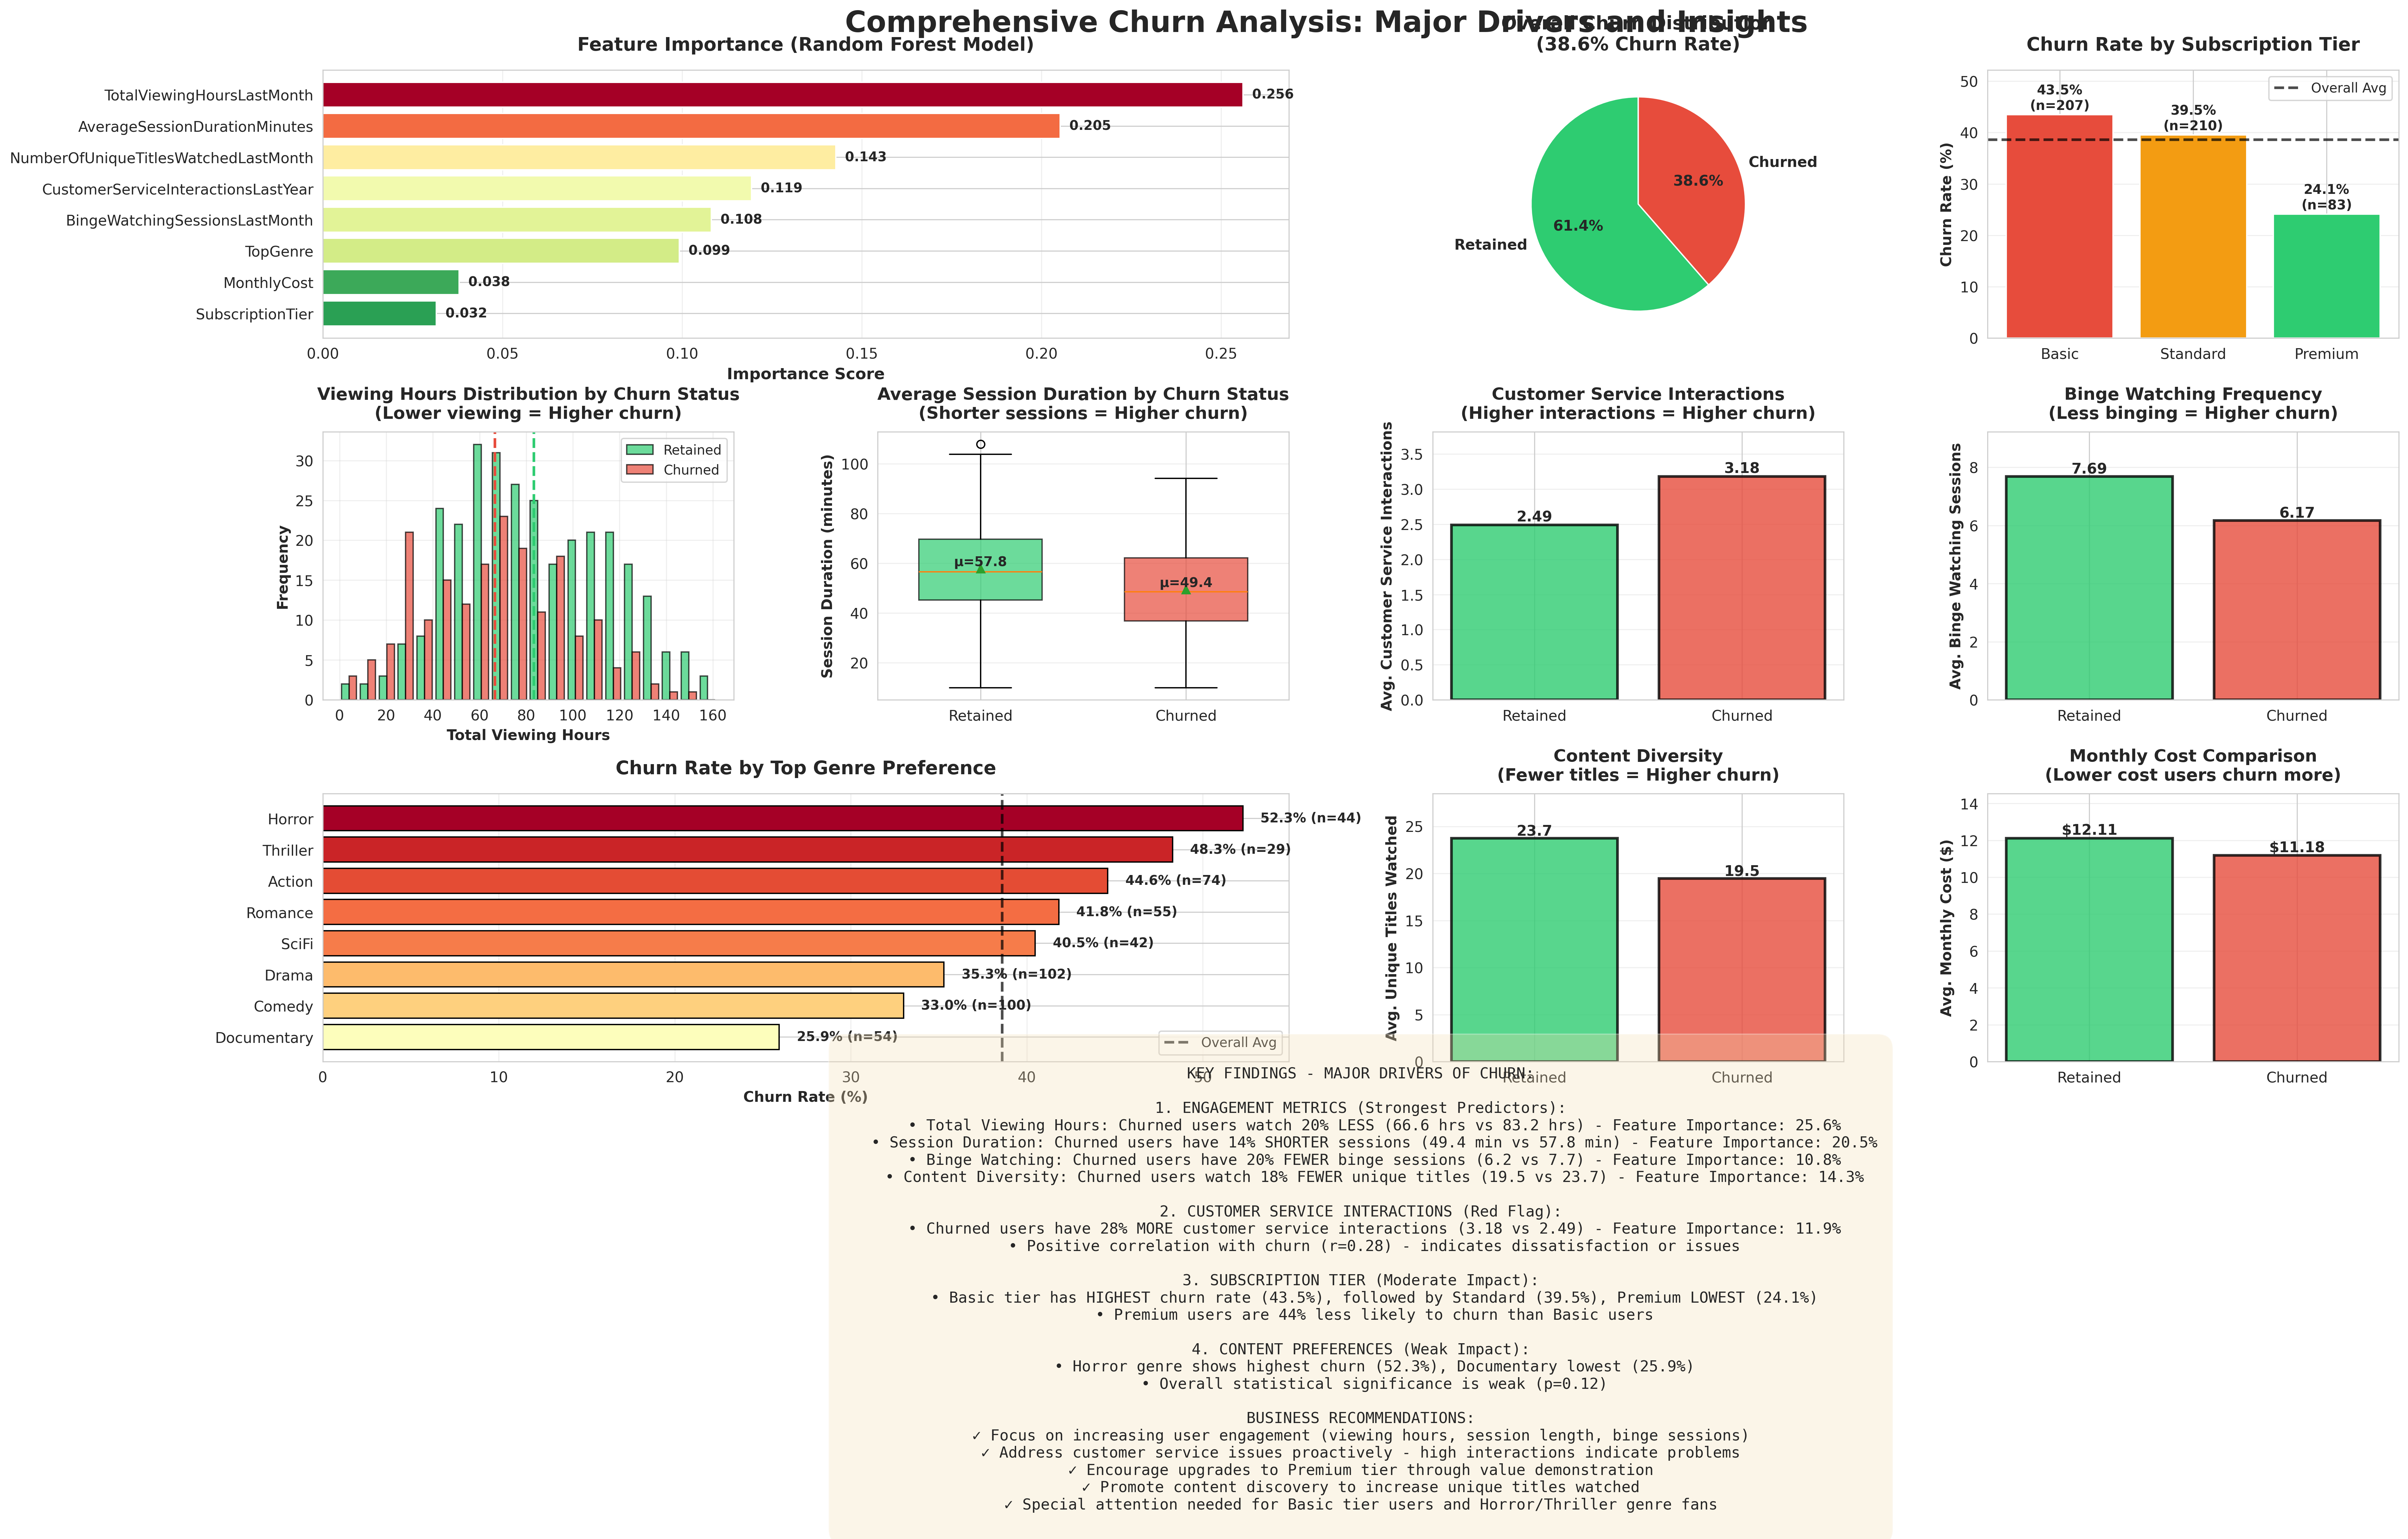

In [48]:
from IPython.display import Image, display
display(Image(filename="./churn_analysis_detailed.png"))